# $(SASA) Regular$

$loss = \alpha \times mse(\hat{\theta_i^a}, \hat{\theta_j^a}) + \beta \times (1-mse(\hat{\theta_i^a}, \hat{\theta_k^b})) + \gamma \times mse(\hat{s_{i+2}^a}, y) + \lambda(\hat{\theta_i^a}^2 + \hat{\theta_k^b}^2 + \hat{\theta_j^a}^2)$

## Experimento Validação

- 100 episódios de Treino
- 10 episódios de Validação
- 1 agente

* Cada agente é treinado com 800 passos dos episódios de treino e testado em 200, os passos de todos os episodios sao embaralhados aleatoriamente
* Resultado intermedário é uma comparacao do parametro estimado em cada passo de teste com o parametro real
* Os a gentes são validados em cada passo dos episódios de validação
* Resultado final é comparacao do parametro estimado em cada passo pelos agentes com o parametro real

In [1]:
import matplotlib.pyplot as plt

from pmbrl.model2 import Model
from pmbrl.data import Experiment_Data, get_data_expanded

# Training

In [2]:
data = Experiment_Data()

data.load(path='training_data_short.csv')
data.build_training_dataset()

,step,episode,p,s,a,r,s_,a_,r_,s__
39,9,3,"(0.05, 1.7)","(-0.091, 0.158, 0.054, -0.043)",1,1.0,"(-0.088, 0.343, 0.053, -0.121)",1.0,1.0,"(-0.081, 0.529, 0.05, -0.199)"
138,0,6,"(0.97, 0.2)","(0.004, -0.016, -0.013, -0.013)",1,1.0,"(0.004, 0.259, -0.013, -2.054)",0.0,1.0,"(0.009, -0.013, -0.054, -0.069)"
135,51,5,"(0.63, 1.5)","(0.144, 0.611, -0.146, -0.786)",1,1.0,"(0.156, 0.8, -0.162, -0.966)",1.0,1.0,"(0.172, 0.99, -0.181, -1.147)"
70,40,3,"(0.05, 1.7)","(0.441, 0.72, -0.169, -0.417)",1,1.0,"(0.456, 0.906, -0.177, -0.514)",1.0,1.0,"(0.474, 1.092, -0.188, -0.611)"
79,6,4,"(0.93, 1.7)","(-0.006, -0.386, 0.103, 0.483)",0,1.0,"(-0.013, -0.579, 0.113, 0.721)",0.0,1.0,"(-0.025, -0.771, 0.127, 0.96)"
...,...,...,...,...,...,...,...,...,...,...
177,1,8,"(0.63, 0.6)","(-0.016, 0.249, -0.018, -0.377)",1,1.0,"(-0.011, 0.449, -0.025, -0.783)",1.0,1.0,"(-0.002, 0.65, -0.041, -1.192)"
22,4,1,"(0.63, 0.3)","(0.031, 0.488, -0.131, -1.722)",1,1.0,"(0.041, 0.71, -0.166, -2.611)",0.0,1.0,"(0.055, 0.499, -0.218, -1.976)"
139,1,6,"(0.97, 0.2)","(0.004, 0.259, -0.013, -2.054)",0,1.0,"(0.009, -0.013, -0.054, -0.069)",0.0,1.0,"(0.008, -0.28, -0.056, 1.812)"
196,9,9,"(0.11, 0.5)","(0.033, -0.218, 0.018, 0.36)",0,1.0,"(0.029, -0.414, 0.025, 0.66)",1.0,1.0,"(0.02, -0.219, 0.038, 0.374)"


In [3]:
model = Model()

loss_param=1e-5

x, y = model.get_features_targets(data.training_dataset)
trainer = model.train(x, y, num_epochs=2000, alpha=loss_param, beta=loss_param, lambda_=loss_param)
train_data = data.get_training_data(trainer, inference_schema=model.inference_schema)
train_data.head()

,epoch,mse_positive,mse_negative,mse_s,regularize,transition,reward
0,0,"[0.15056075155735016, 1.062160849571228]","[0.1354978233575821, 0.9656453132629395]","[0.03955544903874397, 0.3709484934806824, 0.01...",1.787300,1.711367,1.125745
1,1,"[0.15148109197616577, 1.0547441244125366]","[0.1365813910961151, 0.9595555067062378]","[0.03815441206097603, 0.3688499927520752, 0.01...",1.788172,1.697492,1.123631
2,2,"[0.151693657040596, 1.0474268198013306]","[0.137022465467453, 0.9535335302352905]","[0.036815449595451355, 0.36676904559135437, 0....",1.789281,1.683800,1.121556
3,3,"[0.1517556607723236, 1.0401890277862549]","[0.1373240202665329, 0.9475713968276978]","[0.035535480827093124, 0.36471086740493774, 0....",1.790470,1.670280,1.119580
4,4,"[0.1517467051744461, 1.033035397529602]","[0.13755875825881958, 0.9416922330856323]","[0.03431166708469391, 0.3626715838909149, 0.01...",1.791719,1.656925,1.117714


In [4]:
data.training_dataset.head()

,step,episode,p,s,a,r,s_,a_,r_,s__
39,9,3,"(0.05, 1.7)","(-0.091, 0.158, 0.054, -0.043)",1,1.0,"(-0.088, 0.343, 0.053, -0.121)",1.0,1.0,"(-0.081, 0.529, 0.05, -0.199)"
138,0,6,"(0.97, 0.2)","(0.004, -0.016, -0.013, -0.013)",1,1.0,"(0.004, 0.259, -0.013, -2.054)",0.0,1.0,"(0.009, -0.013, -0.054, -0.069)"
135,51,5,"(0.63, 1.5)","(0.144, 0.611, -0.146, -0.786)",1,1.0,"(0.156, 0.8, -0.162, -0.966)",1.0,1.0,"(0.172, 0.99, -0.181, -1.147)"
70,40,3,"(0.05, 1.7)","(0.441, 0.72, -0.169, -0.417)",1,1.0,"(0.456, 0.906, -0.177, -0.514)",1.0,1.0,"(0.474, 1.092, -0.188, -0.611)"
79,6,4,"(0.93, 1.7)","(-0.006, -0.386, 0.103, 0.483)",0,1.0,"(-0.013, -0.579, 0.113, 0.721)",0.0,1.0,"(-0.025, -0.771, 0.127, 0.96)"


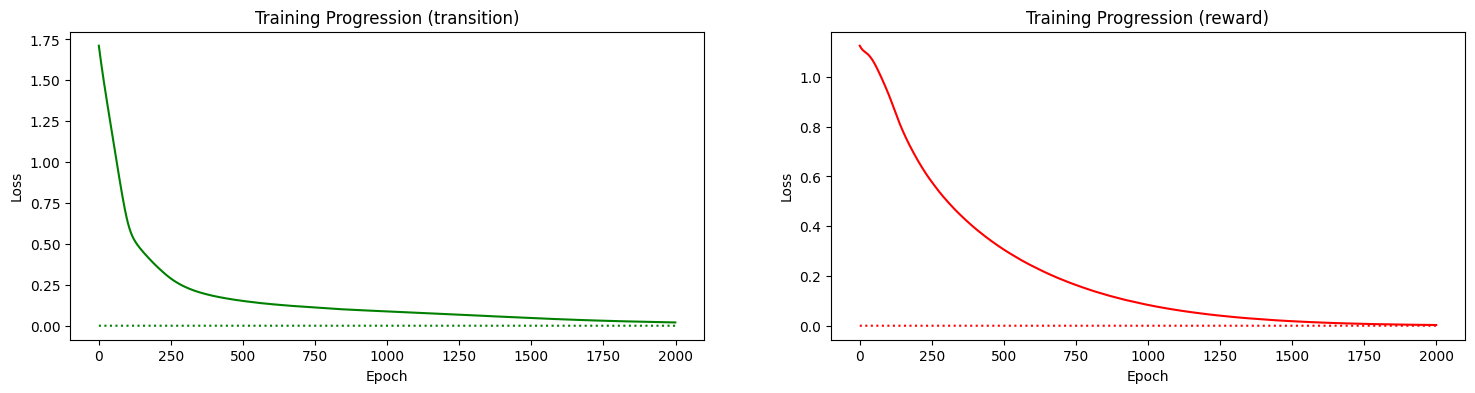

In [5]:
fig, axs = plt.subplots(1, 2, figsize=(18, 4))

data.plot_training_loss(axs[0])
data.plot_training_loss(axs[1], train_data.reward, 'r')

plt.show()

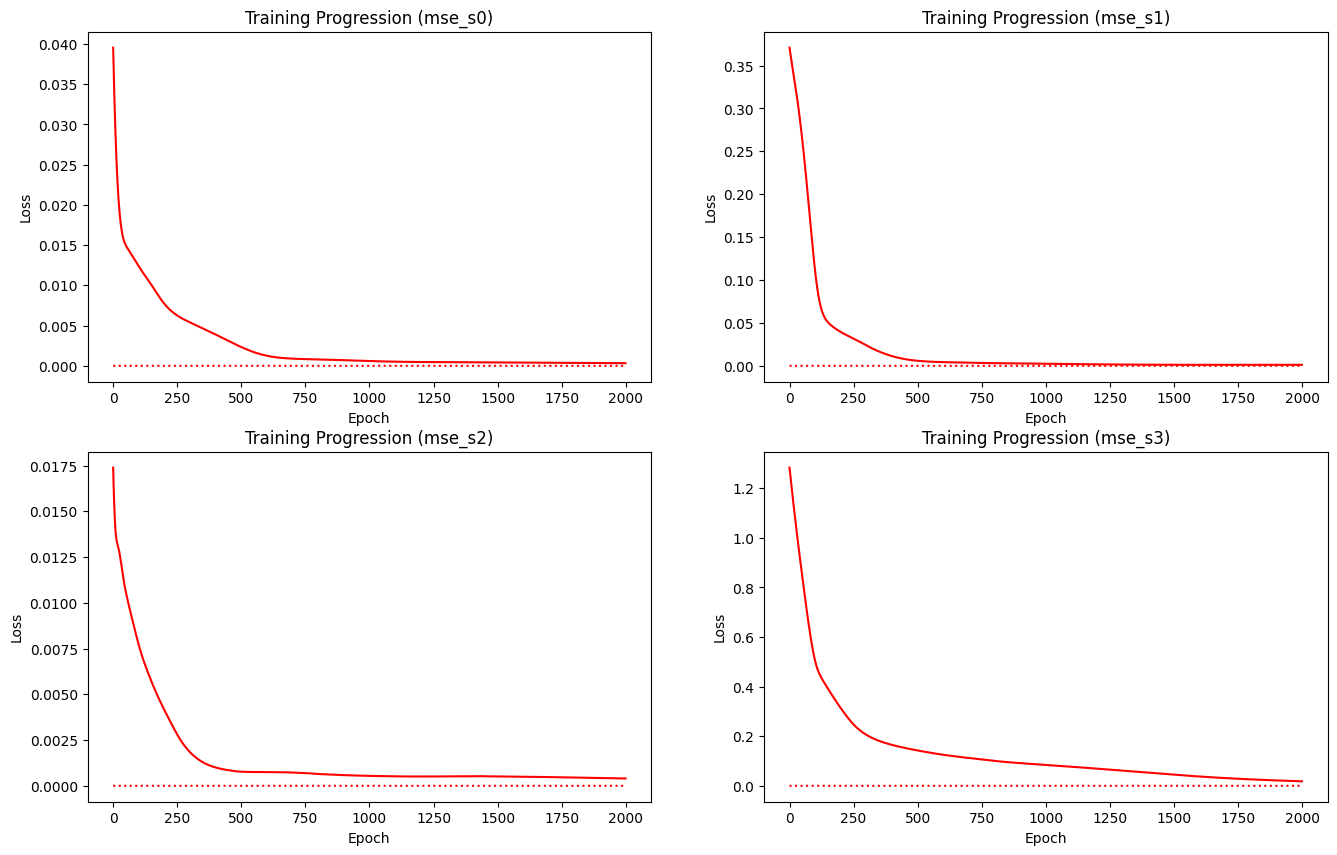

In [6]:
fig, axs = plt.subplots(2, 2, figsize=(16, 10))

expansions = {
    'mse_s': ['mse_s0', 'mse_s1', 'mse_s2', 'mse_s3'],
    'mse_negative': ['mse_negative_p0', 'mse_negative_p1'],
    'mse_positive': ['mse_positive_p0', 'mse_positive_p1'],
}

df = get_data_expanded(train_data, expansions)

for i,col in enumerate(expansions['mse_s']):
    data.plot_training_loss(axs[i//2][i%2], df[col], 'r')

plt.show()

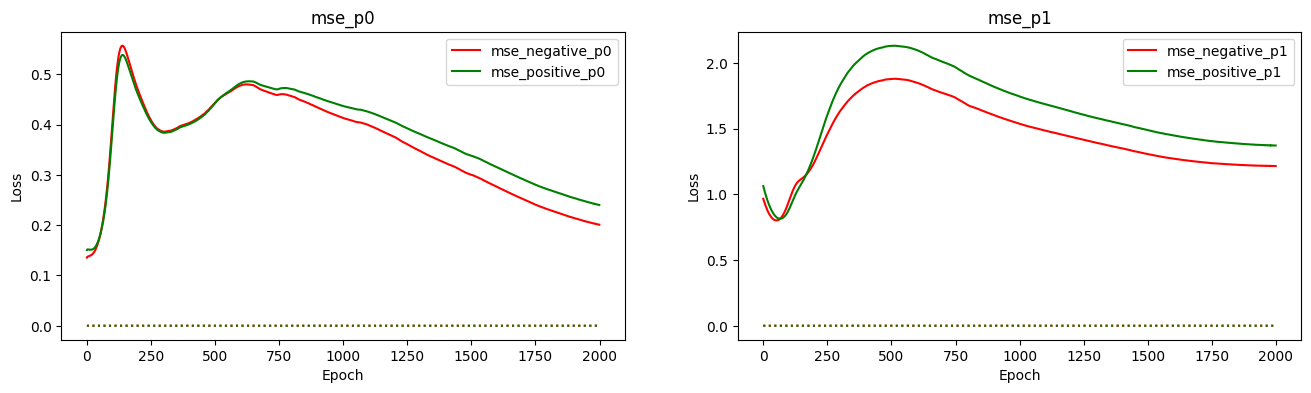

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(16, 4))

expansions = {
    'mse_s': ['mse_s0', 'mse_s1', 'mse_s2', 'mse_s3'],
    'mse_negative': ['mse_negative_p0', 'mse_negative_p1'],
    'mse_positive': ['mse_positive_p0', 'mse_positive_p1'],
}

df = get_data_expanded(train_data, expansions)

for i,(neg, pos) in enumerate(zip(expansions['mse_negative'], expansions['mse_positive'])):
    data.plot_training_loss(axs[i], df[neg], 'r')
    data.plot_training_loss(axs[i], df[pos], 'g')
    axs[i].set_title(f'mse_p{i}')
    axs[i].legend()

plt.show()

## Params

In [8]:
import pandas as pd

training_params = pd.DataFrame(y.numpy(), columns=model.targets_lables)

expansions = {
    'p': ['p0', 'p1']
}
df_trainning = get_data_expanded(data.training_data.loc[(data.training_data.epoch==499)], expansions)

df_trainning_p = pd.DataFrame([], columns=['epoch', 'positive_p0', 'positive_p1', 'negative_p0', 'negative_p1', 'p0', 'p1'])
for epoch in df_trainning.epoch.unique():
    copy = df_trainning[df_trainning.epoch == epoch].copy()[['epoch', 'p0', 'p1']].reset_index(drop=True)
    copy[['sample', 'positive_p0', 'positive_p1', 'negative_p0', 'negative_p1']] = training_params.copy()[['positive_p0', 'positive_p1', 'negative_p0', 'negative_p1']].reset_index()
    df_trainning_p = pd.concat([df_trainning_p, copy])

df_trainning_p.head()

/tmp/ipykernel_10387/580248604.py:14: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_trainning_p = pd.concat([df_trainning_p, copy])


,epoch,positive_p0,positive_p1,negative_p0,negative_p1,p0,p1,sample
0,499,0.05,1.7,0.63,1.5,0.016015,-0.187808,0.0
1,499,0.97,0.2,0.27,1.1,-0.327515,0.858166,1.0
2,499,0.63,1.5,0.05,1.7,-0.530457,-0.105385,2.0
3,499,0.05,1.7,0.63,0.3,-0.441894,-0.421591,3.0
4,499,0.93,1.7,0.63,1.5,0.635666,-0.038396,4.0


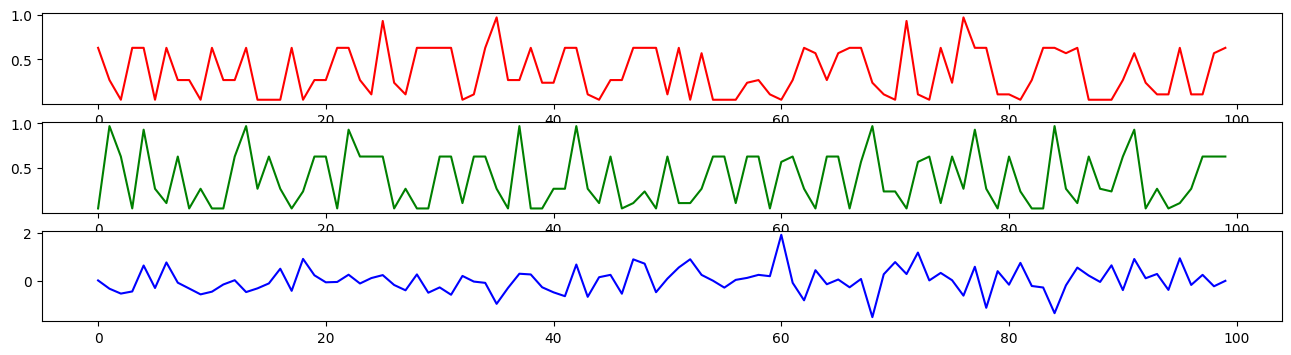

In [9]:
fig, axs = plt.subplots(3, 1, figsize=(16, 4))

axs[0].plot(df_trainning_p.loc[(df_trainning_p.epoch==499) & (df_trainning_p['sample']<100)]['negative_p0'], color='r', label='negative')
axs[1].plot(df_trainning_p.loc[(df_trainning_p.epoch==499) & (df_trainning_p['sample']<100)]['positive_p0'], color='g', label='positve')
axs[2].plot(df_trainning_p.loc[(df_trainning_p.epoch==499) & (df_trainning_p['sample']<100)]['p0'], color='b', label='estimative')

plt.show()

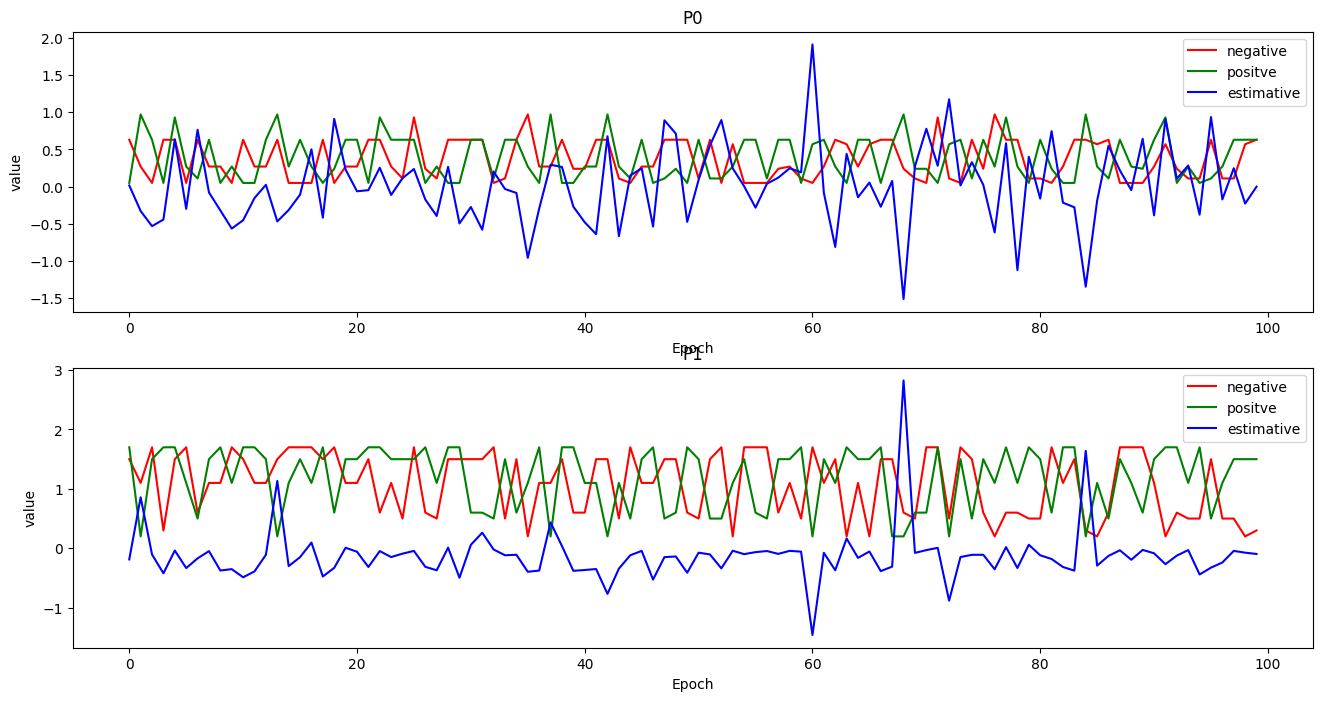

In [10]:
fig, axs = plt.subplots(2,1, figsize=(16, 8))

# df = df_trainning_p.groupby('epoch').mean()
# df = df_trainning_p.groupby('sample').mean()
df = df_trainning_p.loc[(df_trainning_p.epoch==499) & (df_trainning_p['sample']<100)]

axs[0].plot(df['negative_p0'], color='r', label='negative')
axs[0].plot(df['positive_p0'], color='g', label='positve')
axs[0].plot(df['p0'], color='b', label='estimative')

axs[0].set_ylabel('value')
axs[0].set_xlabel('Epoch')
axs[0].set_title(f'P0')
axs[0].legend()

axs[1].plot(df['negative_p1'], color='r', label='negative')
axs[1].plot(df['positive_p1'], color='g', label='positve')
axs[1].plot(df['p1'], color='b', label='estimative')

axs[1].set_ylabel('value')
axs[1].set_xlabel('Epoch')
axs[1].set_title(f'P1')
axs[1].legend()

plt.show()

## Best and worst episodes

In [11]:
data.evaluate_model(model, path='training_data_short.csv')
results = data.get_evaluation_metrics()
results.head()

/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:168: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:181: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed `options` to allow the environment initialisation to be passed additional information.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:168: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3

,step,episode,p,s,a,r,s_,a_,r_,s__,...,estimated_s3,p0,p1,estimated_p0,estimated_p1,rse_s0,rse_s1,rse_s2,rse_s3,rse_r
0,0,0,"(0.24, 0.6)","(-0.041, 0.037, 0.015, -0.0)",0,1.0,"(-0.04, -0.157, 0.015, 0.276)",1.0,1.0,"(-0.043, 0.037, 0.02, 0.009)",...,0.072,0.24,0.6,0.141,0.162,0.000,0.012,0.008,0.063,0.1
1,1,0,"(0.24, 0.6)","(-0.04, -0.157, 0.015, 0.276)",1,1.0,"(-0.043, 0.037, 0.02, 0.009)",1.0,1.0,"(-0.042, 0.231, 0.02, -0.257)",...,-0.337,0.24,0.6,0.102,0.225,0.006,0.007,0.001,0.080,0.1
2,2,0,"(0.24, 0.6)","(-0.043, 0.037, 0.02, 0.009)",1,1.0,"(-0.042, 0.231, 0.02, -0.257)",1.0,1.0,"(-0.038, 0.425, 0.015, -0.523)",...,-0.552,0.24,0.6,0.067,0.233,0.004,0.020,0.001,0.029,0.1
3,3,0,"(0.24, 0.6)","(-0.042, 0.231, 0.02, -0.257)",1,1.0,"(-0.038, 0.425, 0.015, -0.523)",0.0,1.0,"(-0.029, 0.23, 0.005, -0.247)",...,-0.311,0.24,0.6,0.013,0.255,0.002,0.003,0.002,0.064,0.1
4,4,0,"(0.24, 0.6)","(-0.038, 0.425, 0.015, -0.523)",0,1.0,"(-0.029, 0.23, 0.005, -0.247)",0.0,1.0,"(-0.025, 0.036, -0.0, 0.026)",...,-0.065,0.24,0.6,0.029,0.211,0.013,0.030,0.006,0.091,0.1


In [12]:
rmse = results[['episode', 'rse_s0', 'rse_s1', 'rse_s2', 'rse_s3']].groupby('episode').mean().reset_index()
rmse['rmse'] = rmse.rse_s0 + rmse.rse_s1 + rmse.rse_s2 + rmse.rse_s3
rmse_sorted = rmse.sort_values(by='rmse')
epis = rmse.shape[0]

best_episodes = rmse_sorted.head(3).episode.values
worst_episodes = rmse_sorted.tail(3).episode.values
print(f'{best_episodes=}', f'{worst_episodes=}')

best_episodes=array([0, 3, 5]) worst_episodes=array([1, 2, 6])


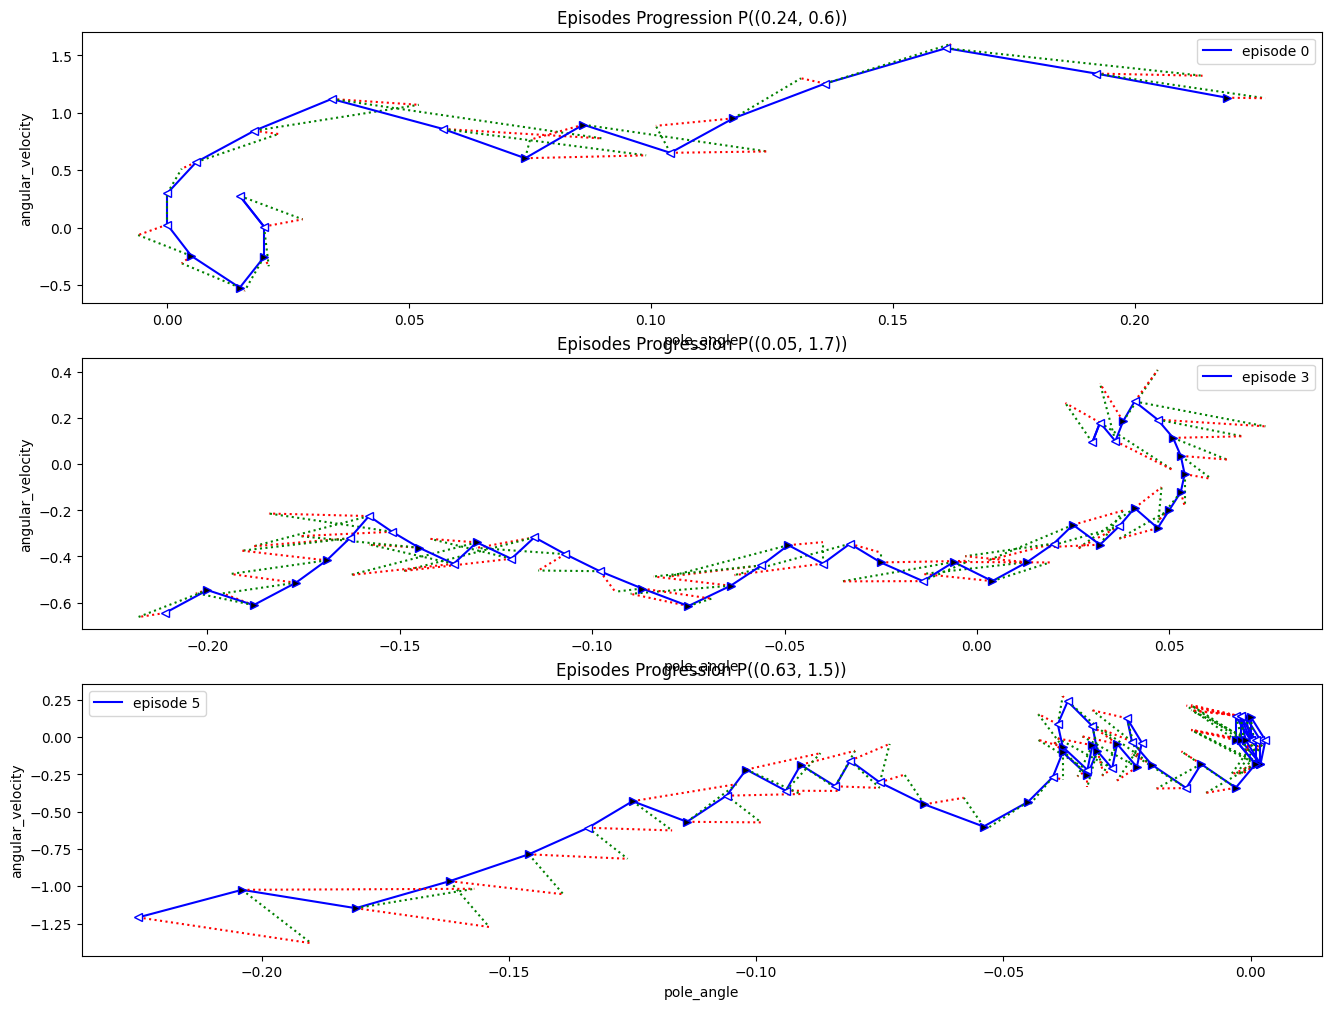

In [13]:
fig, axs = plt.subplots(3, 1, figsize=(16, 12))

for i, epi in enumerate(best_episodes):
    data.plot_episode_progression_with_predictions(axs[i], epi)
plt.show()

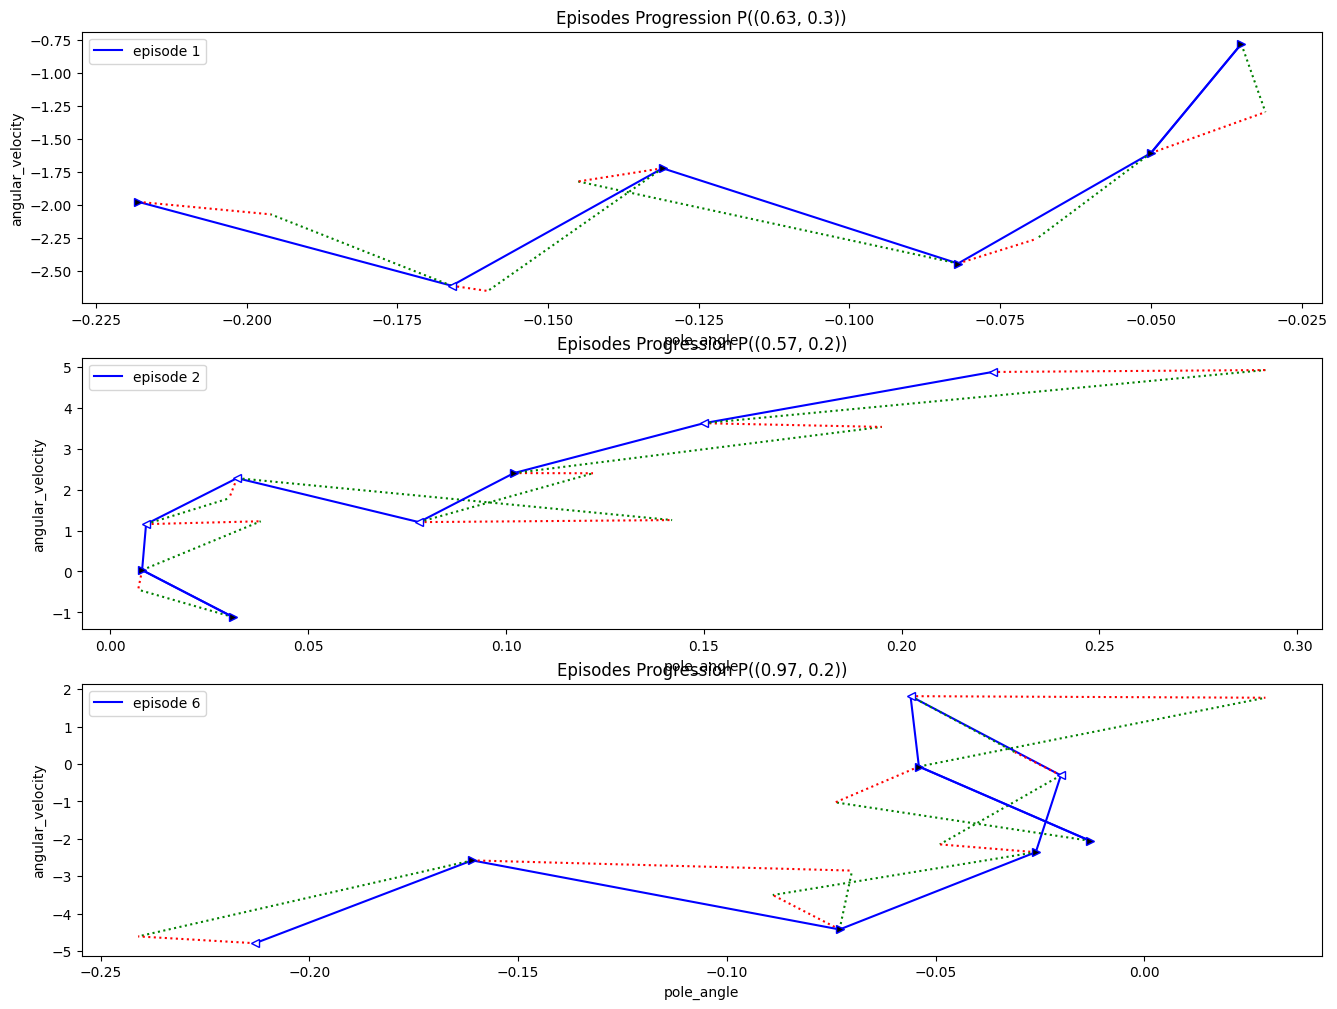

In [14]:
fig, axs = plt.subplots(3, 1, figsize=(16, 12))

for i, epi in enumerate(worst_episodes):
    data.plot_episode_progression_with_predictions(axs[i], epi)
plt.show()

## Kmeans

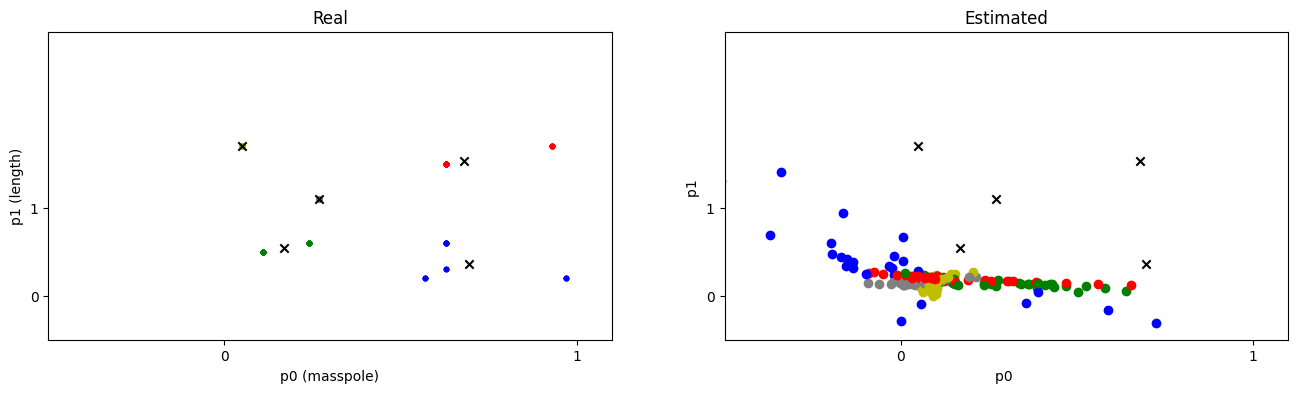

In [15]:
fig, axs = plt.subplots(1, 2, figsize=(16, 4))
data.plot_clusters(axs, results)
plt.show()

# Evaluation

In [20]:
data.evaluate_model(model, path='testing_data_short.csv')
results = data.get_evaluation_metrics()
results.head()

/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:168: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:181: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed `options` to allow the environment initialisation to be passed additional information.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:168: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3

,step,episode,p,s,a,r,s_,a_,r_,s__,...,estimated_s3,p0,p1,estimated_p0,estimated_p1,rse_s0,rse_s1,rse_s2,rse_s3,rse_r
0,0,0,"(0.27, 1.9)","(-0.037, 0.026, -0.021, 0.016)",0,1.0,"(-0.036, -0.159, -0.02, 0.102)",0.0,1.0,"(-0.04, -0.345, -0.018, 0.188)",...,0.182,0.27,1.9,0.104,0.241,0.027,0.033,0.004,0.006,0.1
1,1,0,"(0.27, 1.9)","(-0.036, -0.159, -0.02, 0.102)",0,1.0,"(-0.04, -0.345, -0.018, 0.188)",0.0,1.0,"(-0.047, -0.531, -0.014, 0.274)",...,0.266,0.27,1.9,0.122,0.260,0.028,0.038,0.012,0.008,0.1
2,2,0,"(0.27, 1.9)","(-0.04, -0.345, -0.018, 0.188)",0,1.0,"(-0.047, -0.531, -0.014, 0.274)",1.0,1.0,"(-0.057, -0.345, -0.009, 0.185)",...,0.006,0.27,1.9,0.174,0.273,0.011,0.048,0.033,0.179,0.1
3,3,0,"(0.27, 1.9)","(-0.047, -0.531, -0.014, 0.274)",1,1.0,"(-0.057, -0.345, -0.009, 0.185)",0.0,1.0,"(-0.064, -0.531, -0.005, 0.272)",...,0.326,0.27,1.9,0.111,0.242,0.030,0.037,0.011,0.054,0.1
4,4,0,"(0.27, 1.9)","(-0.057, -0.345, -0.009, 0.185)",0,1.0,"(-0.064, -0.531, -0.005, 0.272)",1.0,1.0,"(-0.075, -0.345, 0.0, 0.183)",...,0.024,0.27,1.9,0.185,0.274,0.012,0.055,0.035,0.159,0.1


In [22]:
results[['rse_s0','rse_s1','rse_s2','rse_s3','rse_r','rse_s0_normalized','rse_s1_normalized','rse_s2_normalized','rse_s3_normalized', 'rse' ,'rse_normalized']].describe()

,rse_s0,rse_s1,rse_s2,rse_s3,rse_r,rse_s0_normalized,rse_s1_normalized,rse_s2_normalized,rse_s3_normalized,rse,rse_normalized
count,148.000000,148.000000,148.000000,148.000000,148.000000,148.000000,148.000000,148.000000,148.000000,148.000000,148.000000
mean,0.025500,0.087122,0.046101,0.632926,0.093919,0.245000,0.184189,0.190501,0.147715,0.791649,0.148608
std,0.019588,0.100488,0.052295,0.911164,0.023979,0.195885,0.212449,0.216095,0.212988,1.067679,0.212220
min,0.001000,0.000000,0.000000,0.001000,0.000000,0.000000,0.000000,0.000000,0.000000,0.044000,0.000000
25%,0.011000,0.022750,0.011000,0.086250,0.100000,0.100000,0.048097,0.045455,0.019928,0.147000,0.020473
50%,0.020000,0.038500,0.028000,0.180500,0.100000,0.190000,0.081395,0.115702,0.041959,0.252000,0.041344
75%,0.036000,0.120500,0.058250,0.863250,0.100000,0.350000,0.254757,0.240702,0.201554,1.064250,0.202793
max,0.101000,0.473000,0.242000,4.279000,0.100000,1.000000,1.000000,1.000000,1.000000,5.075000,1.000000


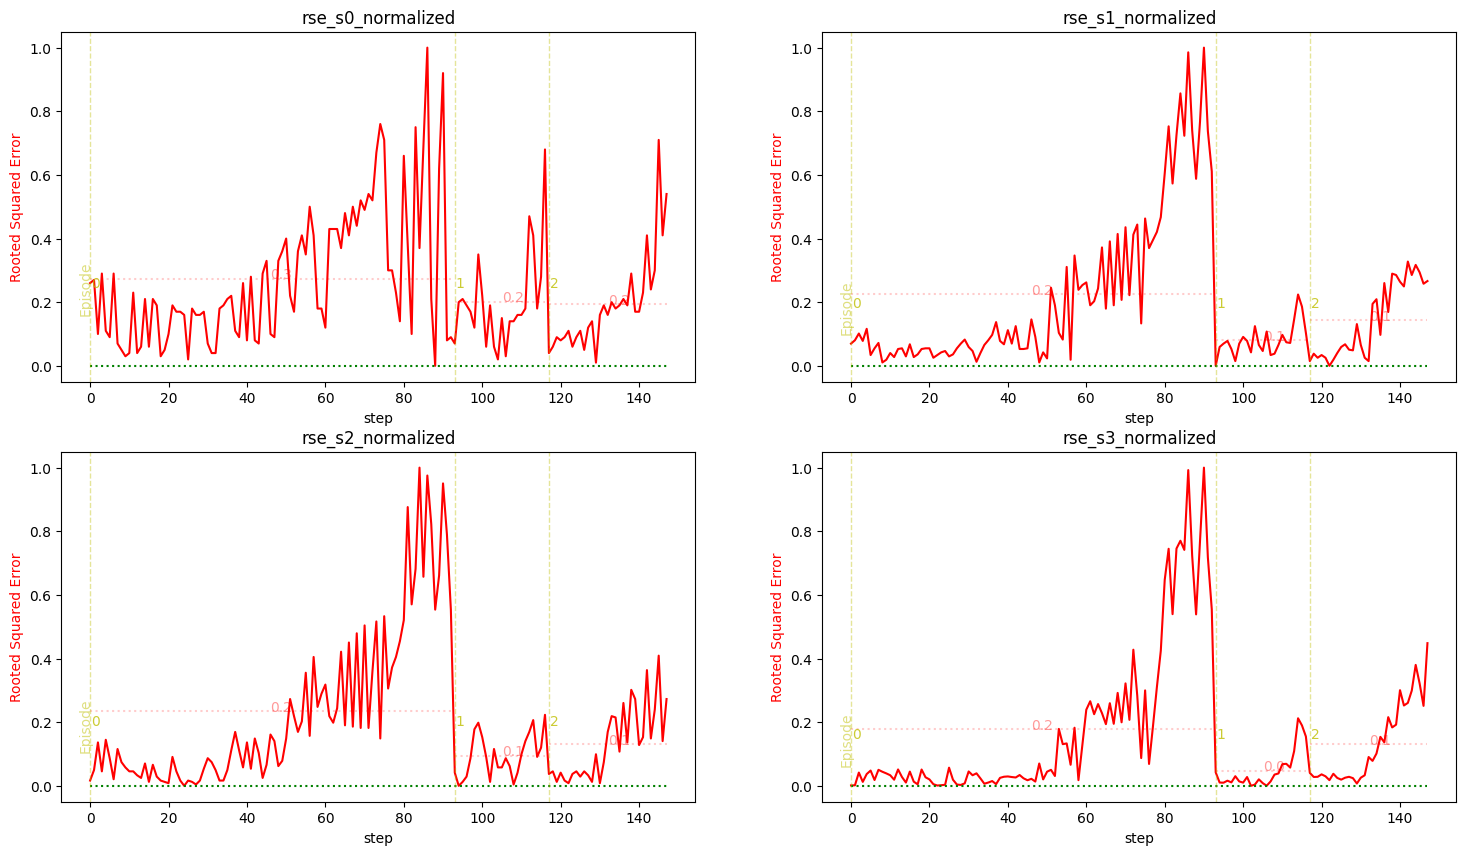

In [23]:
fig, axs = plt.subplots(2, 2, figsize=(18,10))

data.plot_value_through_episodes(axs[0][0], results, 'rse_s0_normalized')
data.plot_value_through_episodes(axs[0][1], results, 'rse_s1_normalized')
data.plot_value_through_episodes(axs[1][0], results, 'rse_s2_normalized')
data.plot_value_through_episodes(axs[1][1], results, 'rse_s3_normalized')

plt.show()

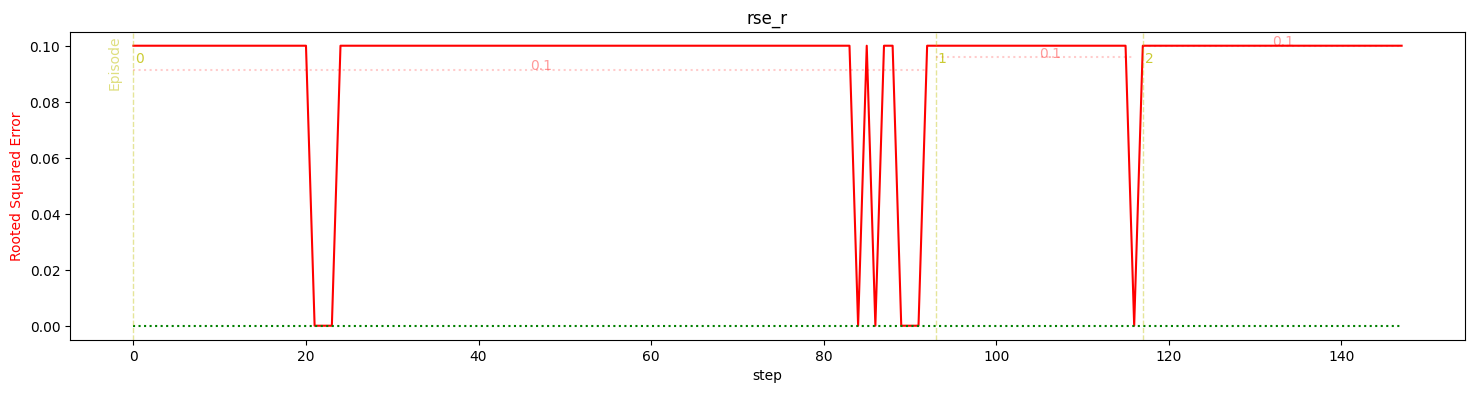

In [24]:
fig, axs = plt.subplots(1, 1, figsize=(18,4))
data.plot_value_through_episodes(axs, results, 'rse_r')
plt.show()

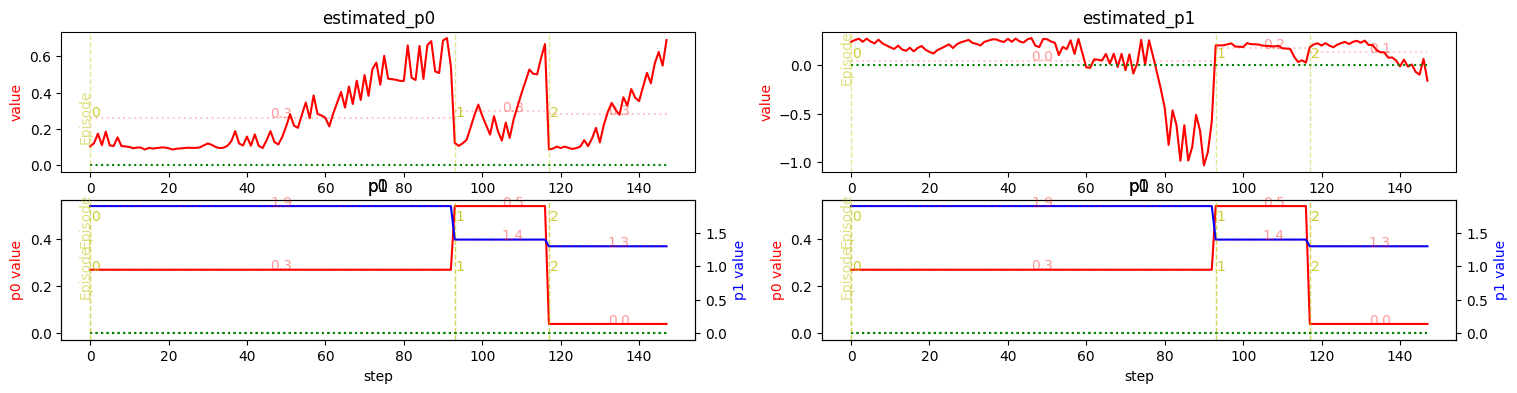

In [25]:
fig, axs = plt.subplots(2, 2, figsize=(18,4))
data.plot_value_through_episodes(axs[0][0], results, 'estimated_p0', y_label='value')
data.plot_value_through_episodes(axs[0][1], results, 'estimated_p1', y_label='value')

data.plot_value_through_episodes(axs[1][0], results, 'p0', y_label='p0 value')
data.plot_value_through_episodes(axs[1][0].twinx(), results, 'p1', y_label='p1 value', color='b')

data.plot_value_through_episodes(axs[1][1], results, 'p0', y_label='p0 value')
data.plot_value_through_episodes(axs[1][1].twinx(), results, 'p1', y_label='p1 value', color='b')

plt.show()

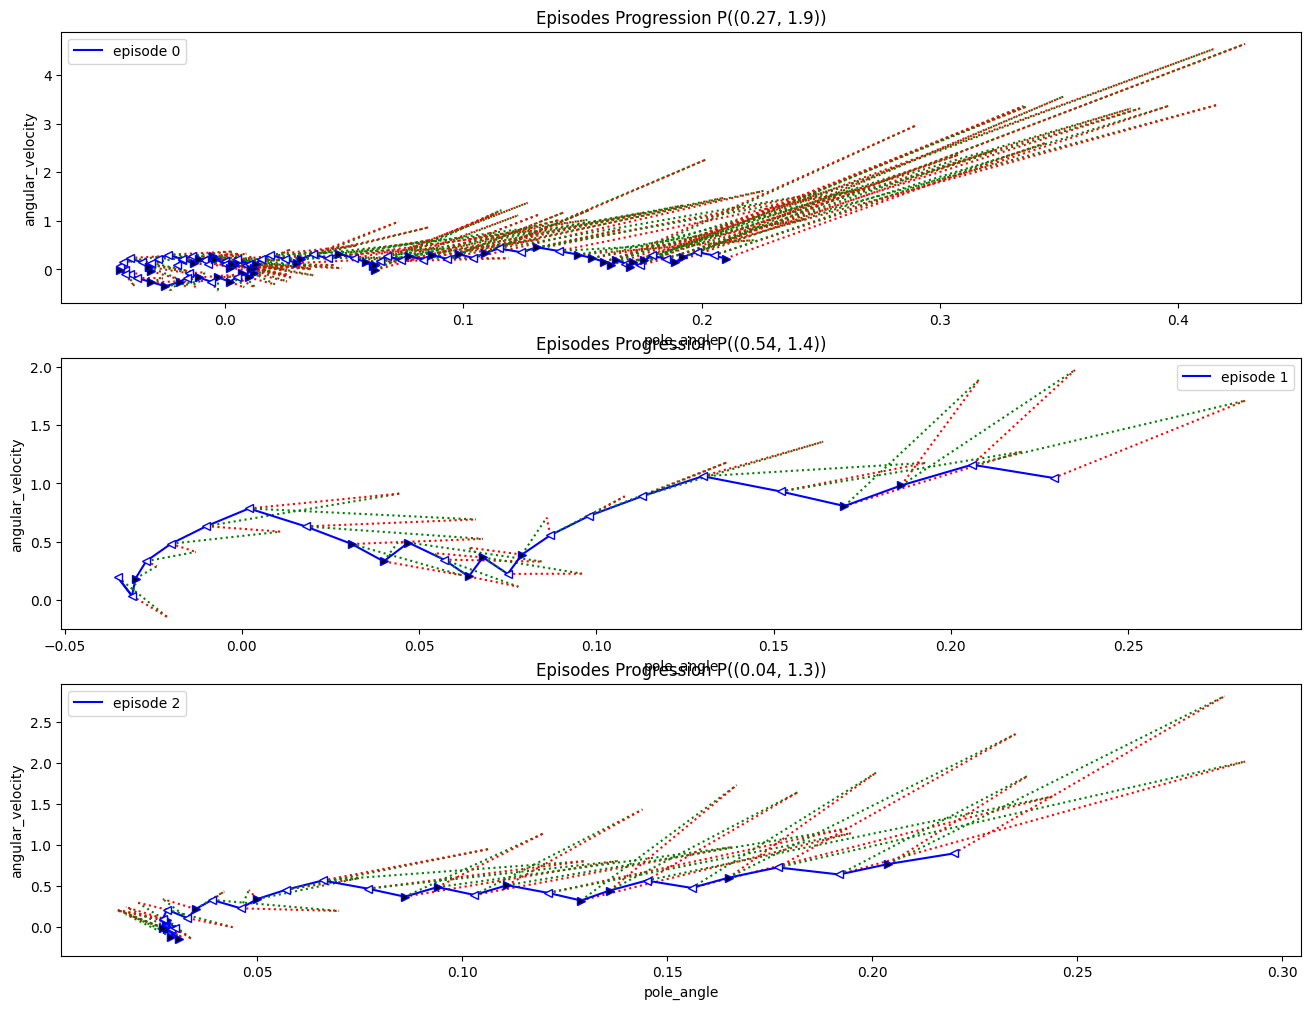

In [26]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(3, 1, figsize=(16, 12))
data.plot_episode_progression_with_predictions(axs[0], 0)
data.plot_episode_progression_with_predictions(axs[1], 1)
data.plot_episode_progression_with_predictions(axs[2], 2)
plt.show()

## Cluster

/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/sklearn/base.py:1473: ConvergenceWarning: Number of distinct clusters (3) found smaller than n_clusters (5). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


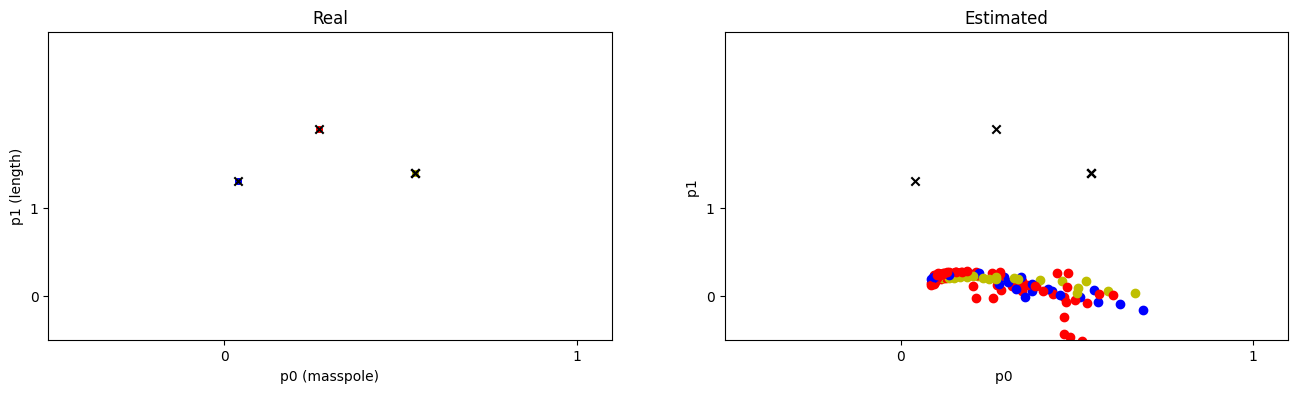

In [27]:
fig, axs = plt.subplots(1, 2, figsize=(16, 4))
data.plot_clusters(axs, results)
plt.show()